# Amblyopia Detection Using Machine Learning

In [52]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


## Load the Dataset



In [ ]:
# Loading the Amblyopia dataset which contains 588 patient records.
df = pd.read_csv("amblyopia_detection_balanced.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Patient_ID,Age,Visual_Acuity_Left,Visual_Acuity_Right,Strabismus,Family_History,Premature_Birth,Eye_Patching_Treatment,Vision_Screening_Result,Refractive_Error,Ocular_Alignment,Amblyopic
0,P0744,6,0.810000,0.880000,No,No,No,No,Pass,0.66,Normal,No
1,P0376,5,0.433772,0.980000,No,No,No,Yes,Fail,0.33,Misaligned,Yes
2,P0054,9,0.970000,0.510000,No,No,Yes,No,Pass,-0.07,Normal,No
3,P0284,3,1.000000,0.550000,No,No,No,No,Pass,-0.39,Normal,No
4,P0542,7,0.750000,0.485591,No,No,No,Yes,Pass,-0.36,Normal,Yes


## Dataset Overview



In [54]:
# Checking the shape, column names, data types, missing values, and target class distribution.

print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Column Distribution:")
print(df['Amblyopic'].value_counts())

Shape of dataset (rows, columns): (588, 12)

Column Names: ['Patient_ID', 'Age', 'Visual_Acuity_Left', 'Visual_Acuity_Right', 'Strabismus', 'Family_History', 'Premature_Birth', 'Eye_Patching_Treatment', 'Vision_Screening_Result', 'Refractive_Error', 'Ocular_Alignment', 'Amblyopic']

Data Types:
 Patient_ID                  object
Age                          int64
Visual_Acuity_Left         float64
Visual_Acuity_Right        float64
Strabismus                  object
Family_History              object
Premature_Birth             object
Eye_Patching_Treatment      object
Vision_Screening_Result     object
Refractive_Error           float64
Ocular_Alignment            object
Amblyopic                   object
dtype: object

Missing Values:
 Patient_ID                 0
Age                        0
Visual_Acuity_Left         0
Visual_Acuity_Right        0
Strabismus                 0
Family_History             0
Premature_Birth            0
Eye_Patching_Treatment     0
Vision_Screening_Re

## Exploratory Data Analysis (EDA)

### Plot 1 : Class Distribution



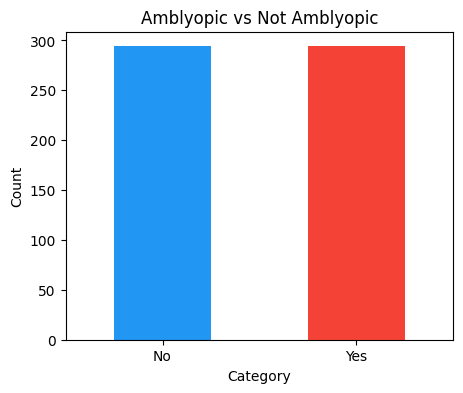

In [ ]:
# Checking if the dataset is balanced between Amblyopic and Non-Amblyopic patients.

plt.figure(figsize=(5, 4))
df['Amblyopic'].value_counts().plot(kind='bar', color=['#2196F3', '#F44336'])
plt.title("Amblyopic vs Not Amblyopic")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Plot 2 : Strabismus vs Amblyopic Status



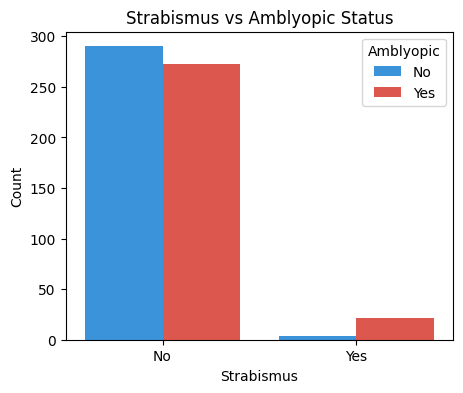

In [ ]:
# Checking if patients with Strabismus (eye misalignment) are more likely to be Amblyopic.

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Strabismus', hue='Amblyopic', palette=['#2196F3', '#F44336'])
plt.title("Strabismus vs Amblyopic Status")
plt.xlabel("Strabismus")
plt.ylabel("Count")
plt.show()

### Plot 3 : Family History vs Amblyopic Status



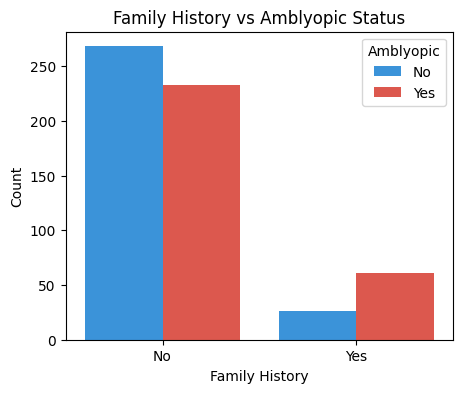

In [ ]:
# Checking if a family history of Amblyopia increases the risk of the condition.

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Family_History', hue='Amblyopic', palette=['#2196F3', '#F44336'])
plt.title("Family History vs Amblyopic Status")
plt.xlabel("Family History")
plt.ylabel("Count")
plt.show()

### Plot 4 : Ocular Alignment vs Amblyopic Status



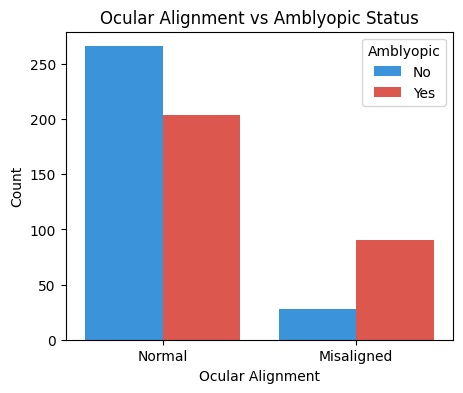

In [ ]:
# Checking how Ocular Alignment (Normal vs Misaligned) relates to Amblyopia.

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Ocular_Alignment', hue='Amblyopic', palette=['#2196F3', '#F44336'])
plt.title("Ocular Alignment vs Amblyopic Status")
plt.xlabel("Ocular Alignment")
plt.ylabel("Count")
plt.show()

## Data Preprocessing

### Drop Unnecessary Column



In [ ]:
# Removing the Patient_ID column as it is just an identifier and has no impact on the prediction.
df = df.drop('Patient_ID', axis=1)
df.head()

,Age,Visual_Acuity_Left,Visual_Acuity_Right,Strabismus,Family_History,Premature_Birth,Eye_Patching_Treatment,Vision_Screening_Result,Refractive_Error,Ocular_Alignment,Amblyopic
0,6,0.810000,0.880000,No,No,No,No,Pass,0.66,Normal,No
1,5,0.433772,0.980000,No,No,No,Yes,Fail,0.33,Misaligned,Yes
2,9,0.970000,0.510000,No,No,Yes,No,Pass,-0.07,Normal,No
3,3,1.000000,0.550000,No,No,No,No,Pass,-0.39,Normal,No
4,7,0.750000,0.485591,No,No,No,Yes,Pass,-0.36,Normal,Yes


### Label Encoding



In [ ]:
# Converting categorical text columns (like Yes/No) into numbers (1/0).
# because Machine Learning models only work with numerical data.

le = LabelEncoder()

cat_cols = ['Strabismus', 'Family_History', 'Premature_Birth', 
            'Eye_Patching_Treatment', 'Vision_Screening_Result', 
            'Ocular_Alignment', 'Amblyopic']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Label Encoding done!")
df.head()

Label Encoding done!


,Age,Visual_Acuity_Left,Visual_Acuity_Right,Strabismus,Family_History,Premature_Birth,Eye_Patching_Treatment,Vision_Screening_Result,Refractive_Error,Ocular_Alignment,Amblyopic
0,6,0.810000,0.880000,0,0,0,0,1,0.66,1,0
1,5,0.433772,0.980000,0,0,0,1,0,0.33,0,1
2,9,0.970000,0.510000,0,0,1,0,1,-0.07,1,0
3,3,1.000000,0.550000,0,0,0,0,1,-0.39,1,0
4,7,0.750000,0.485591,0,0,0,1,1,-0.36,1,1


## Train Test Split



In [ ]:
# Splitting the dataset into 80% training data and 20% testing data. 
# The model learns from training data and is evaluated on testing data.

X = df.drop('Amblyopic', axis=1)
y = df['Amblyopic']

# Splitting data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (470, 10)
Testing size: (118, 10)


## Model Training

### Model 1 : Decision Tree



In [ ]:
# A Decision Tree makes predictions by splitting data based on feature values. It is simple but can overfit.

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


### Model 2 : Random Forest



In [ ]:
# Random Forest creates 100 Decision Trees and combines their results. 
# It reduces overfitting and gives better accuracy than a single Decision Tree.

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


## Model Evaluation

### Decision Tree Results



In [ ]:
# Evaluating the Decision Tree model on test data using Accuracy and Classification Report.
dt_predictions = dt_model.predict(X_test)

print("Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, dt_predictions))
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

Decision Tree Results:
Accuracy: 0.8389830508474576

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.89      0.83        54
           1       0.89      0.80      0.84        64

    accuracy                           0.84       118
   macro avg       0.84      0.84      0.84       118
weighted avg       0.85      0.84      0.84       118



### Random Forest Results



In [ ]:
# Evaluating the Random Forest model on test data. Random Forest performs better than Decision Tree due to ensemble learning.

rf_predictions = rf_model.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, rf_predictions))
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Results:
Accuracy: 0.9067796610169492

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        54
           1       0.92      0.91      0.91        64

    accuracy                           0.91       118
   macro avg       0.91      0.91      0.91       118
weighted avg       0.91      0.91      0.91       118



### Confusion Matrix : Random Forest



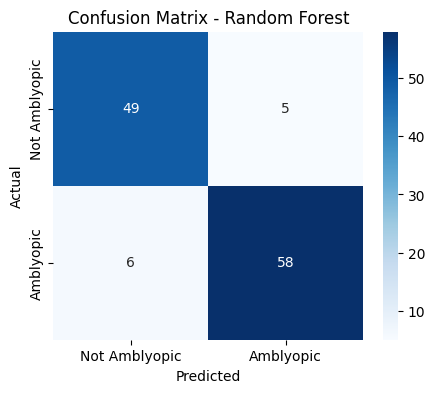

In [ ]:
# The Confusion Matrix shows how many predictions were correct and incorrect for each class.

cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Amblyopic', 'Amblyopic'],
            yticklabels=['Not Amblyopic', 'Amblyopic'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Feature Importance


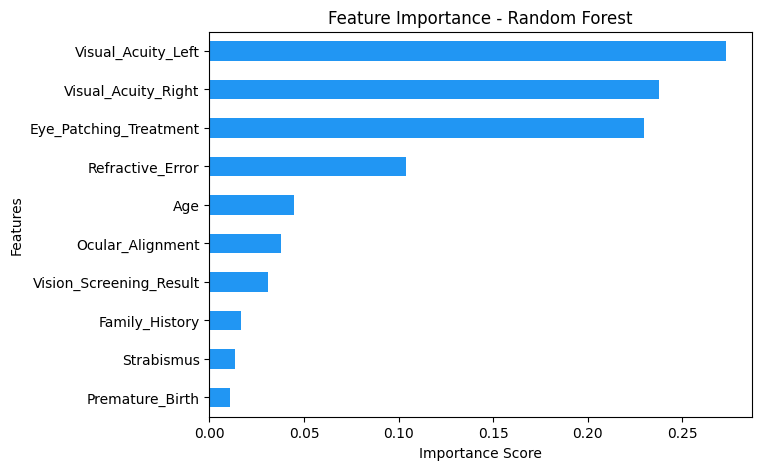

In [ ]:
# Checking which features contributed the most to the Random Forest model's predictions.

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

plt.figure(figsize=(7, 5))
feature_importance.sort_values().plot(kind='barh', color='#2196F3')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## Save the Model

In [ ]:
# Saving the trained Random Forest model as a .pkl file.

joblib.dump(rf_model, 'amblyopia_rf_model.pkl')

print("Model saved successfully as amblyopia_rf_model.pkl")

Model saved successfully as amblyopia_rf_model.pkl
